# AG-HYPOPT · Trial 17

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Sixteen trials recorded, objective order: trial_09 0.1657 (BEST), trial_14 0.1679, trial_05 0.1863, trial_11 0.1883, trial_01 0.1907, trial_07 0.1940, trial_12 0.1941, trial_13 0.1941, trial_08 0.1948, trial_04 0.1987, trial_15 0.2046, trial_16 0.2058, trial_02 0.2075, trial_06 0.2203, trial_03 0.2472, trial_10 0.3727 (worst). Recap: mu_fit is pinned at ~half of mu_true for every config (objective floor); the objective is the gamma term, dominated by low transmission, and it is unstable. The sweet-spot band (high sigma_ref ~22-25, low lr_mu ~5.7-7, high lr_gamma ~0.88-0.92, moderate anneal ~0.41-0.55) produced the two best trials (09/14) but also middling ones (15/16) -- good on average, not robust. TPE (16/5) is exploiting. Context only.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_17'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (16/5 trials)
ID |     ei | params
 1 | 2.7609 | {"gamma_anneal": 0.41783608834444336, "lr_gamma": 0.8624808310784434, "lr_mu": 6.602148311102785, "sigma_ref": 7.428421606735119}
 2 | 0.8394 | {"gamma_anneal": 0.19053068534447945, "lr_gamma": 0.8741895926525745, "lr_mu": 14.331695872695846, "sigma_ref": 16.350796262968892}
 3 | 1.2447 | {"gamma_anneal": 0.6059235689872927, "lr_gamma": 0.33193777082111653, "lr_mu": 8.83914420333955, "sigma_ref": 21.766502120930312}
 4 | 3.0363 | {"gamma_anneal": 0.3627865547823337, "lr_gamma": 0.9414111621948082, "lr_mu": 5.0, "sigma_ref": 25.0}
 5 | 3.1114 | {"gamma_anneal": 0.387069329855276, "lr_gamma": 0.8515851952605118, "lr_mu": 6.792855630315614, "sigma_ref": 25.0}
 6 | 2.7249 | {"gamma_anneal": 0.3833689274913794, "lr_gamma": 0.9650812011582491, "lr_mu": 5.0, "sigma_ref": 21.654181396767566}
 7 | 2.8501 | {"gamma_anneal": 0.5342129752363021, "lr_gamma": 0.9284407668557295, "lr_mu": 5.0, "sigma_ref": 24.554512540225577}
 8 | 3.098

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

TPE (16/5) ranks by expected improvement. The highest-EI candidate is candidate 5 (EI 3.11): gamma_anneal 0.387, lr_gamma 0.852, lr_mu 6.79, sigma_ref 25.0 -- an almost exact replica of the current best recipe trial_09 (sigma_ref 25.0, lr_mu 6.55, lr_gamma 0.884, anneal 0.410), and correspondingly of the second-best trial_14. The runner-up candidates (8: sigma_ref 11.87; 4: lr_gamma 0.941) move further from that recipe. Since the top-EI pick is a tight replication of the best-region recipe, the choice is clear. I choose candidate 5.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 5               # highest-EI TPE pick = near-exact replica of the best recipe


chosen: {'gamma_anneal': 0.387069329855276, 'lr_gamma': 0.8515851952605118, 'lr_mu': 6.792855630315614, 'sigma_ref': 25.0}
Running  1nW Trans05 ... 

μ 9.39 -> 4.70 | γ 8.5 -> 2.88 | NLL 1.29


Running  1nW Trans20 ... 

μ 17.32 -> 8.67 | γ 8.5 -> 9.49 | NLL 3.05


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 51.13 | γ 14.1 -> 13.68 | NLL 3.12


Running 3nW Trans100 ... 

μ 175.71 -> 86.98 | γ 14.1 -> 13.69 | NLL 2.67



Total: 2.4 min


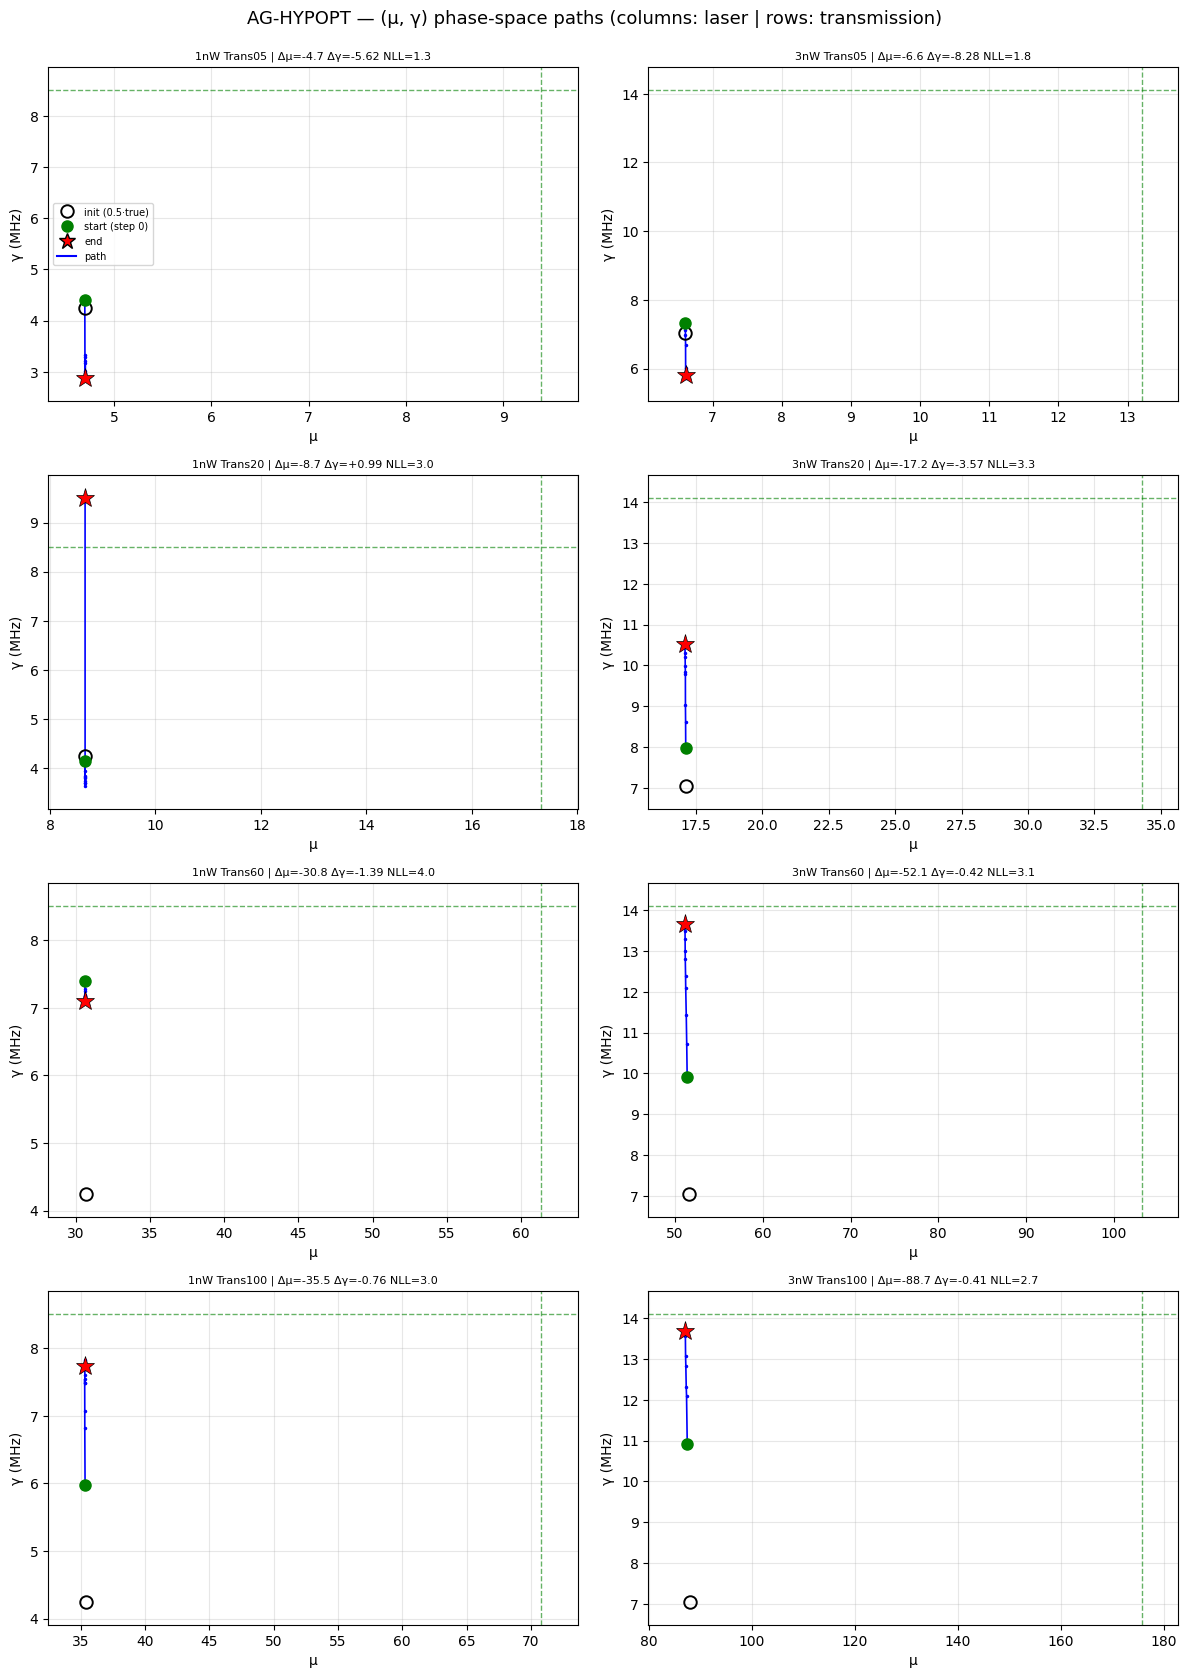

trial finished in 2.5 min
objective = 0.1816 ± 0.0349
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    4.70   -49.9 |     8.50    2.88   -66.1
1nW Trans20    17.32    8.67   -50.0 |     8.50    9.49   +11.7
1nW Trans60    61.37   30.62   -50.1 |     8.50    7.11   -16.4
1nW Trans100   70.82   35.34   -50.1 |     8.50    7.74    -8.9
3nW Trans05    13.20    6.62   -49.9 |    14.10    5.82   -58.7
3nW Trans20    34.28   17.10   -50.1 |    14.10   10.53   -25.3
3nW Trans60   103.20   51.13   -50.5 |    14.10   13.68    -3.0
3nW Trans100  175.71   86.98   -50.5 |    14.10   13.69    -2.9

μ: RMSE 40.658 (rel 50.1%, bias -30.519) | γ: RMSE 3.818 (rel 33.5%, bias -2.432)


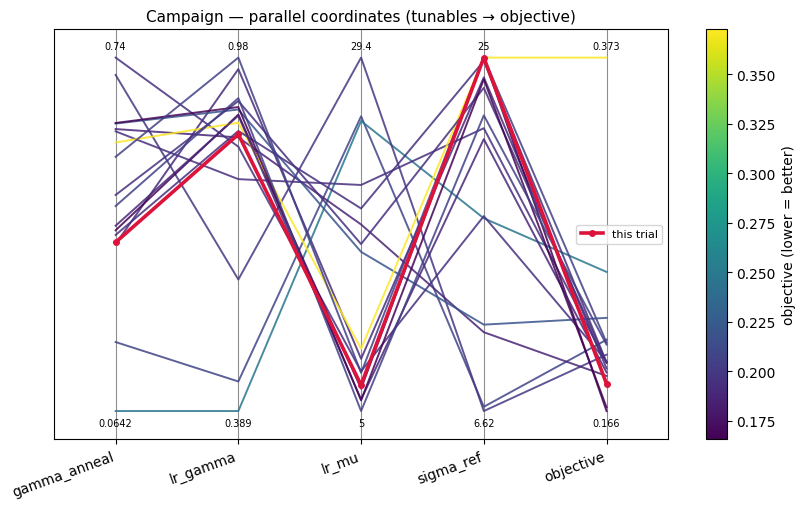

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 17, twelfth TPE-driven trial; highest-EI pick, a near-exact replica of the best recipe: sigma_ref 25.0, lr_mu 6.79, lr_gamma 0.852, gamma_anneal 0.387. Result: objective 0.1816 +/- 0.0349 -- the fourth-best of the campaign (behind trial_09 0.1657, trial_14 0.1679, trial_05 0.1863, ahead of trial_11 0.1883); runtime 2.5 min. mu_fit is unchanged at a uniform ~half-truth (Delta-mu% -49.9 to -50.5; mu RMSE 40.66, relative 50.1%). gamma_fit: mid/high transmission good (3 nW Trans60/100: -3.0/-2.9%; 1 nW Trans20 overshoots +11.7%) but 1 nW/3 nW Trans05 still collapsed (-66.1%/-58.7%), gamma RMSE 3.82 (relative 33.5%). So a very close replica of trial_09 again landed solidly (top-quartile) but did not reproduce the 0.1657 best.

**Summary:** Trial 17 (sigma_ref 25.0, lr_mu 6.79, lr_gamma 0.852, gamma_anneal 0.387) -> objective 0.1816 +/- 0.0349, fourth best; near-exact replica of trial_09 but Trans05 gamma still collapsed.
**Key insight:** A near-identical copy of the best recipe gave a top-quartile but clearly non-best result, reinforcing that trial_09's 0.1657 was substantially a favourable low-transmission gamma draw rather than a uniquely optimal configuration.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
No new structural notes; the real-data attractor note from trial_01 still stands.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 17 (sigma_ref 25.0, lr_mu 6.79, lr_gamma 0.852, gamma_anneal 0.387): objective 0.1816 +/- 0.0349, fourth best; near-exact replica of trial_09 but Trans05 gamma still collapsed (-66%/-59%)'
KEY_INSIGHT = 'A near-identical copy of the best recipe gave a top-quartile but clearly non-best result -- trial_09 0.1657 was substantially a favourable low-transmission gamma draw, not a uniquely optimal configuration.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_17 | current best: trial_09


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_18.ipynb. Open it and follow its cells from the top.
